<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Aprendizaje Automático Avanzado</h1>
    <h3>Random Forest (Bosques Aleatorios)</h3>
    
</div>

> El algoritmo **Random Forest** es uno de los **algoritmos avanzados** más usados y confiables del Machine Learning. Combina cientos de árboles de decisión en un "bosque" para lograr predicciones mucho más **precisas y estables** que un árbol individual. Es un método de ensamble de tipo **bagging** y un referente para datos estrucuturados y tabulares.

## ¿Qué es un Random Forest?

Un **Random Forest** (bosque aleatorio) es un conjunto de **muchos árboles de decisión** entrenados sobre versiones ligeramente distintas de los datos. La predicción final se obtiene por:

- **Voto mayoritario** entre los árboles (clasificación), o
- **Promedio** de las predicciones (regresión).

> **Idea:** un árbol solo se equivoca fácilmente; pero si preguntamos a **cientos de árboles diversos** y promediamos, los errores individuales tienden a **cancelarse** y queda la señal correcta.

```mermaid
flowchart TD
    D[Dataset de entrenamiento] --> S1[Muestra bootstrap 1]
    D --> S2[Muestra bootstrap 2]
    D --> S3[Muestra bootstrap N]
    S1 --> T1[Árbol 1]
    S2 --> T2[Árbol 2]
    S3 --> T3[Árbol N]
    T1 --> V[Voto mayoritario / promedio]
    T2 --> V
    T3 --> V
    V --> P[Predicción final]
```

## Las dos fuentes de aleatoriedad

Lo que hace "aleatorio" al bosque (y lo que lo hace funcionar) son **dos** mecanismos que **decorrelacionan** los árboles:

#### Bagging (Bootstrap Aggregating)
Cada árbol se entrena con una **muestra bootstrap**: se toman `n` ejemplos **con reemplazo** del dataset original. Así cada árbol ve un subconjunto ligeramente distinto.

#### Selección aleatoria de variables (*feature bagging*)
En **cada división**, el árbol solo considera un **subconjunto aleatorio de variables** (por defecto $\sqrt{p}$ en clasificación, siendo $p$ el total de variables), en lugar de todas.

> **¿Por qué es clave?** Si todos los árboles pudieran usar todas las variables, la variable más fuerte dominaría **todos** los árboles y estos serían muy parecidos (correlacionados). Limitar las variables **fuerza la diversidad**, y la diversidad es lo que reduce la varianza del ensamble.

```mermaid
flowchart LR
    A[Bootstrap de filas] --> C[Árboles diversos]
    B[Subconjunto de variables<br/>por división] --> C
    C --> D[Errores decorrelacionados]
    D --> E[Menor varianza<br/>mejor generalización]
```

## Comprension del Algoritmo

Para construir un bosque de `B` árboles:

1. **Para** `b = 1, ..., B`:
   - Tomar una muestra **bootstrap** del dataset (n ejemplos con reemplazo).
   - Hacer crecer un árbol de decisión; en cada nodo, elegir la mejor división **solo entre un subconjunto aleatorio de variables**.
   - Dejar crecer el árbol (normalmente sin poda).
2. **Predecir** agregando los `B` árboles (voto mayoritario o promedio).

> Cada árbol tiene **alta varianza** (sobreajusta), pero al **promediar** muchos árboles poco correlacionados, la varianza del conjunto baja drásticamente sin aumentar el sesgo.

## Error Out-of-Bag (OOB)

Como cada árbol se entrena con una muestra bootstrap, en promedio **~37 %** de los datos **no** se usan para ese árbol (quedan *out-of-bag*). Esos ejemplos sirven como un **conjunto de validación gratuito**:

- Para cada muestra, se predice usando **solo** los árboles que **no** la vieron.
- El **OOB score** es una estimación honesta del rendimiento, ¡sin necesidad de un set de validación aparte!

> Matemáticamente, la probabilidad de que un ejemplo **no** entre en un bootstrap de tamaño $n$ es $(1 - 1/n)^n \to e^{-1} \approx 0.368$.

## Ejemplo de un modelo de random forest

Comparemos un **árbol único** contra un **Random Forest** en el dataset real del Titanic, y usemos el **OOB score**.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split


In [11]:
# Dataset
data = fetch_openml('titanic', version=1, as_frame=True)
df = data.frame

In [12]:
y = df['survived'].astype(int)
X = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].copy()
X['pclass'] = X['pclass'].astype(int)
X['sex'] = (X['sex'] == 'female').astype(int)
X['embarked'] = X['embarked'].fillna('S')
X = pd.get_dummies(X, columns=['embarked'], drop_first=True)
X['age'] = X['age'].astype(float).fillna(X['age'].astype(float).median())
X['fare'] = X['fare'].astype(float).fillna(X['fare'].astype(float).median())

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Entrenamiento:', X_train.shape, '| Test:', X_test.shape)

Entrenamiento: (1047, 8) | Test: (262, 8)


In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Árbol único de referencia
tree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)

# Random Forest con OOB score activado
rf = RandomForestClassifier(
    n_estimators=300, max_features='sqrt', oob_score=True,
    random_state=42, n_jobs=-1,
).fit(X_train, y_train)

print('Árbol único   -> test accuracy:', round(accuracy_score(y_test, tree.predict(X_test)), 4))
print('Random Forest -> test accuracy:', round(accuracy_score(y_test, rf.predict(X_test)), 4))
print('Random Forest -> OOB score   :', round(rf.oob_score_, 4))

Árbol único   -> test accuracy: 0.7786
Random Forest -> test accuracy: 0.7901
Random Forest -> OOB score   : 0.7755


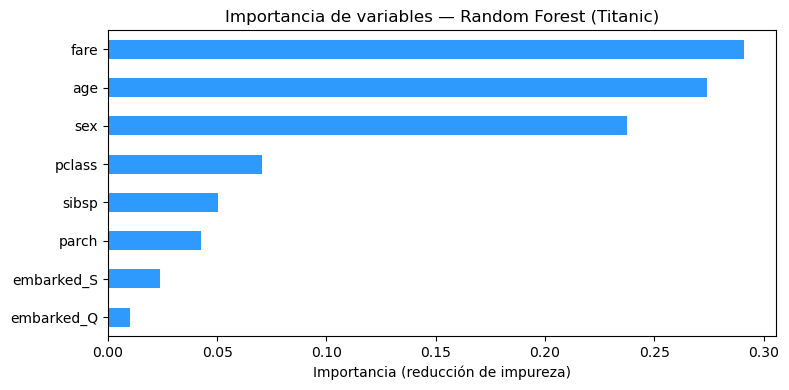

In [15]:
# Importancia de variables del bosque
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 4))
imp.plot.barh(color='#2E9AFE')
plt.xlabel('Importancia (reducción de impureza)')
plt.title('Importancia de variables — Random Forest (Titanic)')
plt.tight_layout()
plt.show()

## Ejemplo de un modelo de Random Forest (regresión)

Ahora un problema de **regresión** con 20 640 viviendas reales. Compararemos el árbol único contra el bosque.

In [16]:
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

cal = fetch_california_housing(as_frame=True)
Xr, yr = cal.data, cal.target
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.2, random_state=42)

tree_r = DecisionTreeRegressor(random_state=42).fit(Xr_tr, yr_tr)
rf_r = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(Xr_tr, yr_tr)

def reporta(nombre, modelo):
    p = modelo.predict(Xr_te)
    print(f'{nombre:<16} RMSE={np.sqrt(mean_squared_error(yr_te, p)):.4f} | R2={r2_score(yr_te, p):.4f}')

reporta('Árbol único', tree_r)
reporta('Random Forest', rf_r)

Árbol único      RMSE=0.7037 | R2=0.6221
Random Forest    RMSE=0.5034 | R2=0.8066


### Importancia por permutación
La importancia basada en impureza puede sesgarse hacia variables con muchos valores. La **importancia por permutación** es más fiable: mide cuánto empeora el modelo al **barajar** cada variable.

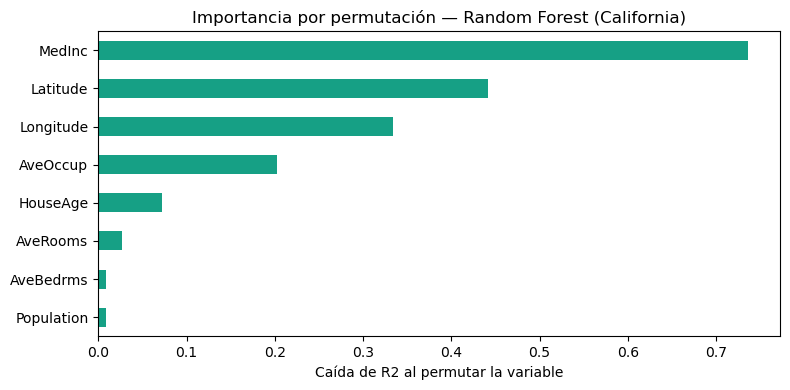

In [17]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf_r, Xr_te, yr_te, n_repeats=10, random_state=42, n_jobs=-1)
perm = pd.Series(result.importances_mean, index=Xr.columns).sort_values()

plt.figure(figsize=(8, 4))
perm.plot.barh(color='#16a085')
plt.xlabel('Caída de R2 al permutar la variable')
plt.title('Importancia por permutación — Random Forest (California)')
plt.tight_layout()
plt.show()

## Hiperparámetros clave

| Hiperparámetro | Qué controla | Recomendación |
|---|---|---|
| `n_estimators` | Número de árboles | Más es mejor (se estabiliza); 100–500 típico |
| `max_features` | Variables por división | `'sqrt'` (clasif.), `1.0`/`'sqrt'` (regr.) |
| `max_depth` | Profundidad de cada árbol | `None` (completo) suele ir bien |
| `min_samples_leaf` | Muestras mínimas por hoja | Subir para regularizar |
| `bootstrap` | Usar muestreo con reemplazo | `True` (necesario para OOB) |
| `n_jobs` | Núcleos de CPU en paralelo | `-1` para usar todos |

Veamos cómo se **estabiliza** el rendimiento al aumentar el número de árboles:

C:\Users\uie70742\.conda\envs\nlp_curso_2026\lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
C:\Users\uie70742\.conda\envs\nlp_curso_2026\lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
C:\Users\uie70742\.conda\envs\nlp_curso_2026\lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


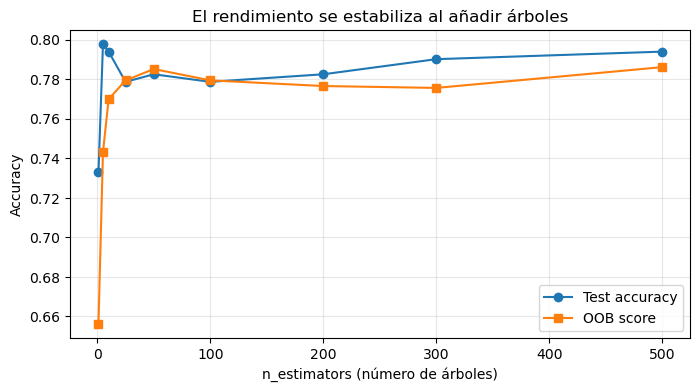

In [18]:
n_arboles = [1, 5, 10, 25, 50, 100, 200, 300, 500]
test_acc, oob_acc = [], []

for n in n_arboles:
    m = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    test_acc.append(accuracy_score(y_test, m.predict(X_test)))
    oob_acc.append(m.oob_score_)

plt.figure(figsize=(8, 4))
plt.plot(n_arboles, test_acc, 'o-', label='Test accuracy')
plt.plot(n_arboles, oob_acc, 's-', label='OOB score')
plt.xlabel('n_estimators (número de árboles)')
plt.ylabel('Accuracy')
plt.title('El rendimiento se estabiliza al añadir árboles')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

> A diferencia del boosting, **añadir más árboles a un Random Forest no causa sobreajuste**: el rendimiento sube y luego se **estabiliza**. Más árboles solo cuesta más cómputo.

### Ventajas y desventajas

|  Ventajas |  Desventajas |
|---|---|
| Muy **preciso** y robusto, poco *tuning* | Menos **interpretable** que un árbol único |
| **Reduce el sobreajuste** de los árboles | Modelo **pesado** (cientos de árboles) |
| Estima el error con **OOB** (sin validación aparte) | Predicción más **lenta** que un árbol |
| Da **importancia de variables** | Puede ser superado por *gradient boosting* afinado |
| Maneja no linealidades e interacciones | No extrapola fuera del rango visto (regresión) |

### Random Forest vs. otras opciones
| | Árbol único | **Random Forest** | Gradient Boosting |
|---|---|---|---|
| Estrategia | 1 árbol | Bagging (paralelo) | Boosting (secuencial) |
| Reduce sobre todo | — | **Varianza** | **Sesgo** |
| Riesgo de sobreajuste | Alto | Bajo | Medio (requiere ajuste) |
| Facilidad de uso | Alta | **Alta** | Media |

## En resumen podemos concluir que:

- **Random Forest** = **bagging de árboles** + **selección aleatoria de variables** en cada división.
- Esas dos fuentes de aleatoriedad **decorrelacionan** los árboles y **reducen la varianza**, mejorando la generalización.
- El **OOB score** ofrece una estimación gratuita del rendimiento.
- Es **robusto**, preciso y de referencia para **datos tabulares**; añadir árboles no lo sobreajusta.
- Para exprimir aún más precisión en tabular, el siguiente paso es el **Gradient Boosting** (XGBoost, LightGBM, CatBoost).

  [scikit-learn — Forests of randomized trees](https://scikit-learn.org/stable/modules/ensemble.html#forest)
